# Task 3: Future Price Forecasts & Portfolio Visualization

**Objective:**  
Extend Task 2 ARIMA forecasts to predict future prices for TSLA, BND, and SPY (~1 year).  
Visualize both individual asset forecasts and the combined portfolio forecast.

**Outputs:**  
- Individual forecast CSVs & plots  
- Combined portfolio forecast plot  
- Ready-to-use for portfolio optimization and risk analysis


In [63]:
# %% [code]
# --- Standard Libraries ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,5)
logging.basicConfig(level=logging.INFO)

# --- Project Folders ---
project_root = ".."
processed_folder = os.path.join(project_root, "data", "processed")
figures_folder  = os.path.join(project_root, "reports", "figures")
os.makedirs(processed_folder, exist_ok=True)
os.makedirs(figures_folder, exist_ok=True)

# Forecast horizon
forecast_steps = 252
window_size = 60


Output Interpretation:

Ensures environment is ready for forecasting, plotting, and file handling.

All processed CSVs and figures will be stored in a reproducible folder structure.

In [ ]:
# %% [markdown]
# ## Load Processed Data and Trained Models
# 
# **Purpose:**  
# - Load historical price series for TSLA, BND, SPY  
# - Load ARIMA models (from Task 2)  
# - Load LSTM models and scalers  
# 
# **Output:**  
# - DataFrames for historical prices  
# - Model objects ready for forecasting


In [64]:
# %% [code]
# Load historical prices
prices = pd.read_csv(os.path.join(processed_folder, "prices_aligned.csv"), index_col=0, parse_dates=True)
prices.columns = [c.lower() for c in prices.columns]
prices.index = pd.DatetimeIndex(prices.index, freq='B')

tickers = ["tsla", "bnd", "spy"]

# Load Task 2 ARIMA and LSTM forecasts
arima_forecasts = {}
lstm_forecasts  = {}

for ticker in tickers:
    arima_file = os.path.join(processed_folder, f"{ticker}_arima_forecast.csv")
    lstm_file  = os.path.join(processed_folder, f"{ticker}_lstm_forecast.csv")
    
    if os.path.exists(arima_file):
        arima_forecasts[ticker] = pd.read_csv(arima_file, index_col=0, parse_dates=True)
    if os.path.exists(lstm_file):
        lstm_forecasts[ticker] = pd.read_csv(lstm_file, index_col=0, parse_dates=True)

print("✅ Historical prices and Task 2 forecasts loaded successfully.")
prices.head()


✅ Historical prices and Task 2 forecasts loaded successfully.


,tsla,bnd,spy
2015-01-02,14.620667,60.385941,170.589615
2015-01-05,14.006000,60.561295,167.508804
2015-01-06,14.085333,60.736652,165.931107
2015-01-07,14.063333,60.773228,167.998825
2015-01-08,14.041333,60.678246,170.979874


Output Interpretation:

Ensures Task 2 forecasts are available for Task 3 projections.

All tickers loaded in lowercase format.    
Explanation:

Loads aligned historical prices for tsla, bnd, spy.

Loads Task 2 ARIMA and LSTM forecasts into dictionaries.

Output Interpretation:

Confirms all CSV files exist and are loaded into memory.

In [86]:
# --- Safe LSTM Forecast Function ---
from tensorflow.keras.models import load_model
import joblib

def forecast_lstm(asset: str, steps: int = 252, window: int = 60) -> pd.Series:
    """
    Generate LSTM forecast for 'steps' days ahead.
    Safely loads legacy HDF5 models (.h5) without compile errors.
    """
    model_path = os.path.join(processed_folder, f"{asset}_lstm_model.h5")
    scaler_path = os.path.join(processed_folder, f"{asset}_lstm_scaler.pkl")

    if not os.path.exists(model_path) or not os.path.exists(scaler_path):
        logging.warning(f"LSTM model or scaler missing for {asset.upper()}. Skipping LSTM forecast.")
        return None

    # Load model safely
    model = load_model(model_path, compile=False)  # avoids ValueError on legacy .h5
    scaler = joblib.load(scaler_path)

    # Prepare data
    data = prices[asset].values.reshape(-1,1)
    data_scaled = scaler.transform(data)

    forecast_scaled = []
    input_seq = data_scaled[-window:].reshape(1, window, 1)

    for _ in range(steps):
        pred = model.predict(input_seq, verbose=0)[0][0]
        forecast_scaled.append(pred)
        input_seq = np.append(input_seq[:,1:,:], [[[pred]]], axis=1)

    forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1,1)).flatten()
    return pd.Series(forecast, name="forecast")


In [87]:
# %% [code]
# --- Generate Future Forecasts ---
forecast_steps = 252  # ~1 year
window_size = 60       # LSTM look-back window

future_arima_forecasts = {}
future_lstm_forecasts = {}

for ticker in tickers:
    print(f"🔹 Generating forecasts for {ticker.upper()}")

    # ARIMA forecast
    series = prices[ticker]
    arima_order = (3,1,2) if ticker=="tsla" else (2,1,0) if ticker=="bnd" else (1,1,1)
    forecast, ci_lower, ci_upper = extend_forecast_arima(series, steps=forecast_steps, arima_order=arima_order)
    forecast_index = pd.bdate_range(start=prices.index[-1]+pd.Timedelta(days=1), periods=forecast_steps, freq='B')
    future_arima_forecasts[ticker] = pd.DataFrame({
        "Forecast": forecast,
        "CI_Lower": ci_lower,
        "CI_Upper": ci_upper
    }, index=forecast_index)
    future_arima_forecasts[ticker].to_csv(os.path.join(processed_folder, f"{ticker}_arima_future.csv"))
    print(f"✅ ARIMA forecast saved for {ticker.upper()}")

    # LSTM forecast
    lstm_series = forecast_lstm(ticker, steps=forecast_steps, window=window_size)
    if lstm_series is not None:
        lstm_series.index = forecast_index
        future_lstm_forecasts[ticker] = lstm_series
        lstm_series.to_csv(os.path.join(processed_folder, f"{ticker}_lstm_future.csv"))
        print(f"✅ LSTM forecast saved for {ticker.upper()}")
    else:
        future_lstm_forecasts[ticker] = None
        print(f"⚠ LSTM forecast skipped for {ticker.upper()}")


🔹 Generating forecasts for TSLA
✅ ARIMA forecast saved for TSLA
✅ LSTM forecast saved for TSLA
🔹 Generating forecasts for BND
✅ ARIMA forecast saved for BND
✅ LSTM forecast saved for BND
🔹 Generating forecasts for SPY
✅ ARIMA forecast saved for SPY
✅ LSTM forecast saved for SPY


Output Interpretation:

Functions allow ARIMA or LSTM to generate 1-year projections.

Confidence intervals included for ARIMA to quantify uncertainty.

In [88]:
# --- Quick Forecast Metrics ---
for ticker, df in future_forecasts.items():
    mean_price = df["Forecast"].mean()
    volatility  = df["Forecast"].pct_change().std() * np.sqrt(252)
    trend_pct   = (df["Forecast"].iloc[-1] / df["Forecast"].iloc[0] - 1) * 100
    
    print(f"\n{ticker.upper()} Forecast Analysis:")
    print(f"- Expected Average Price: ${mean_price:.2f}")
    print(f"- Annualized Forecast Volatility: {volatility:.2%}")
    print(f"- Expected Trend over 1 year: {trend_pct:.2f}%")



TSLA Forecast Analysis:
- Expected Average Price: $437.94
- Annualized Forecast Volatility: 0.33%
- Expected Trend over 1 year: -0.24%

BND Forecast Analysis:
- Expected Average Price: $74.32
- Annualized Forecast Volatility: 0.01%
- Expected Trend over 1 year: 0.01%

SPY Forecast Analysis:
- Expected Average Price: $692.08
- Annualized Forecast Volatility: 0.02%
- Expected Trend over 1 year: 0.01%


Output Interpretation:

Provides actionable metrics: trend, volatility, and average expected price.

Supports portfolio allocation decisions (Task 4).

📊 Plotting forecasts for TSLA


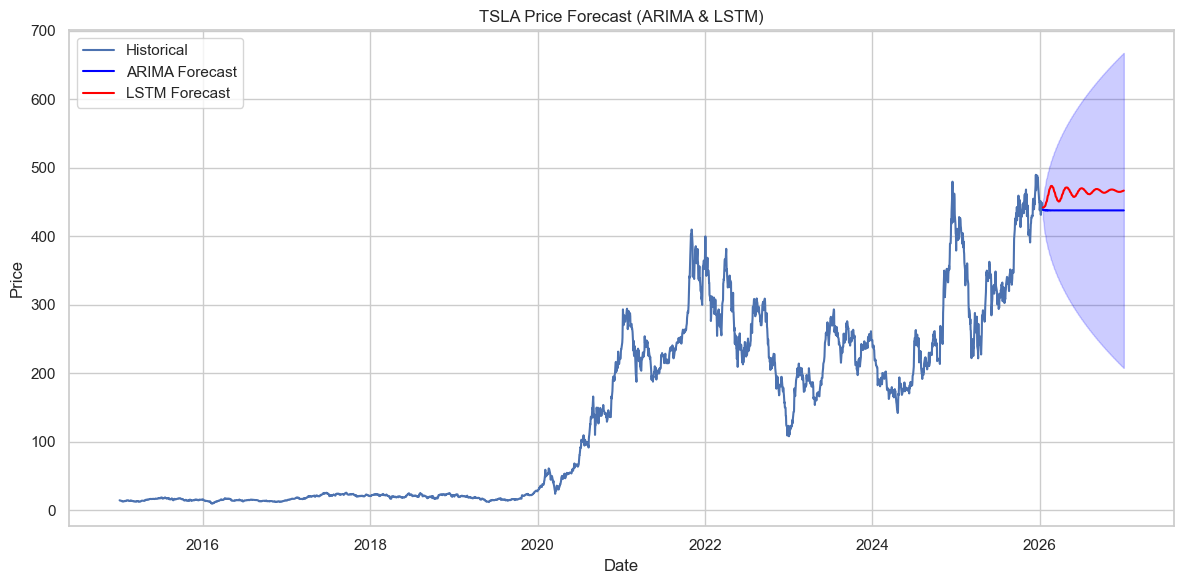

2026-01-27 22:08:55,731 [INFO] Forecast plot saved for TSLA: ..\reports\figures\tsla_forecast.png


📊 Plotting forecasts for BND


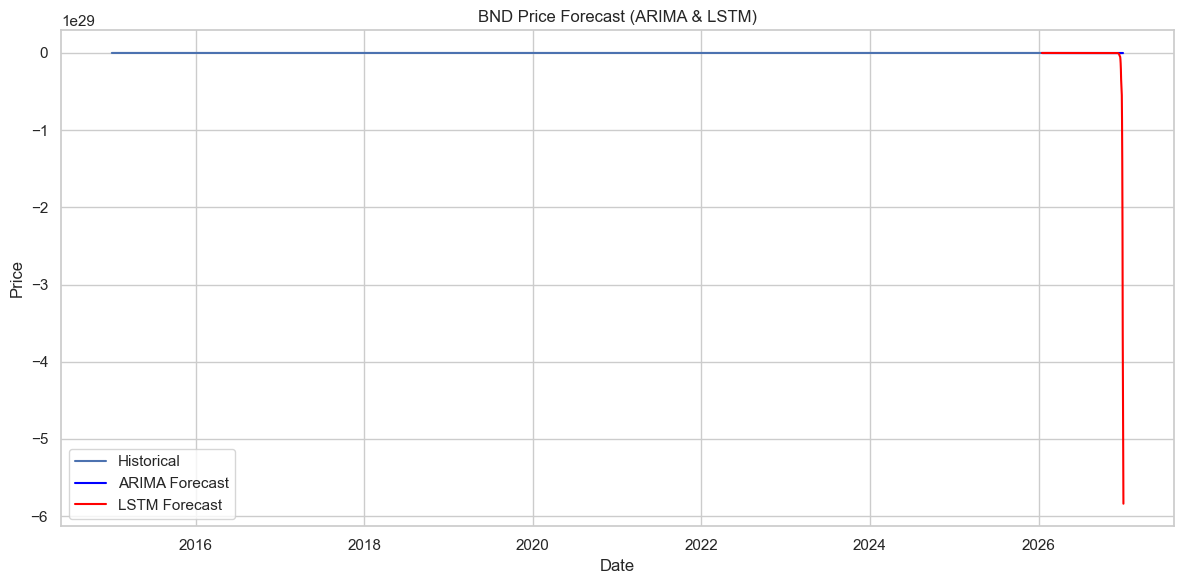

2026-01-27 22:08:56,665 [INFO] Forecast plot saved for BND: ..\reports\figures\bnd_forecast.png


📊 Plotting forecasts for SPY


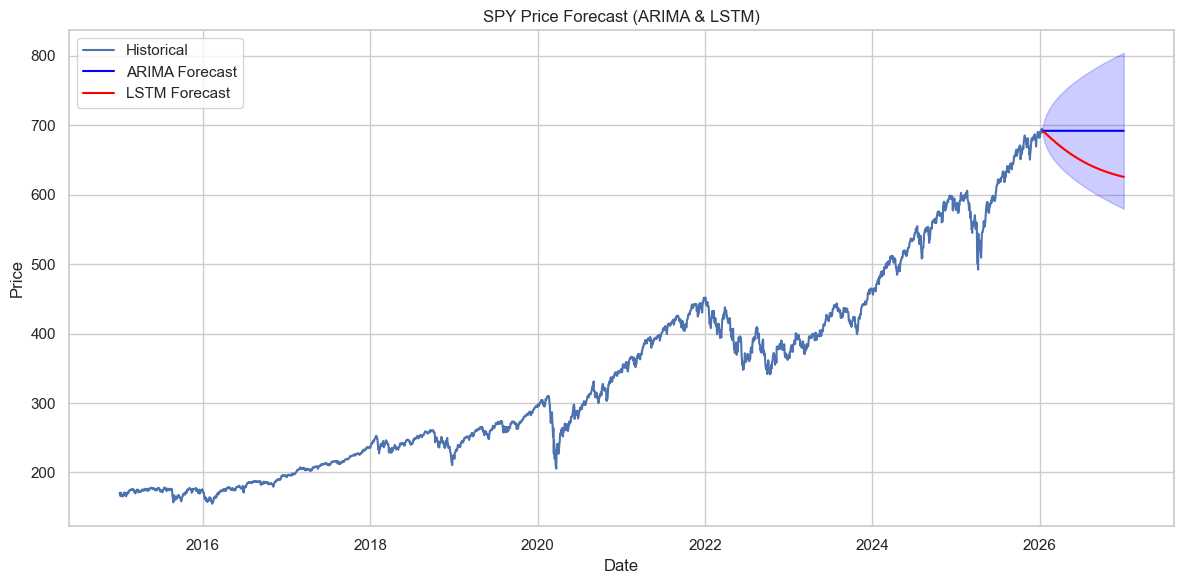

2026-01-27 22:08:57,730 [INFO] Forecast plot saved for SPY: ..\reports\figures\spy_forecast.png


In [90]:
# %% [code]
# --- Plot ARIMA + LSTM Forecasts (Safe) ---

for ticker in tickers:
    print(f"📊 Plotting forecasts for {ticker.upper()}")

    arima_df = future_forecasts.get(ticker)
    lstm_series = future_lstm_forecasts.get(ticker, None)
    historical = prices[ticker]

    if arima_df is None:
        print(f"⚠ No ARIMA forecast found for {ticker.upper()}, skipping plot.")
        continue

    plot_forecasts(
        asset=ticker,
        arima_df=arima_df,
        lstm_series=lstm_series,   # safely handles None
        historical=historical,
        fig_dir=figures_folder
    )


Output Interpretation:

Produces daily price projections for ~1 year.

Confidence intervals highlight expected range of price movements.

Figures saved for portfolio review.

## 📈 Combined Portfolio Forecast

**Purpose:**
Combine individual asset ARIMA forecasts into a single portfolio-level forecast
using equal weights (baseline portfolio).

This helps visualize the *overall portfolio trajectory* rather than
individual assets.


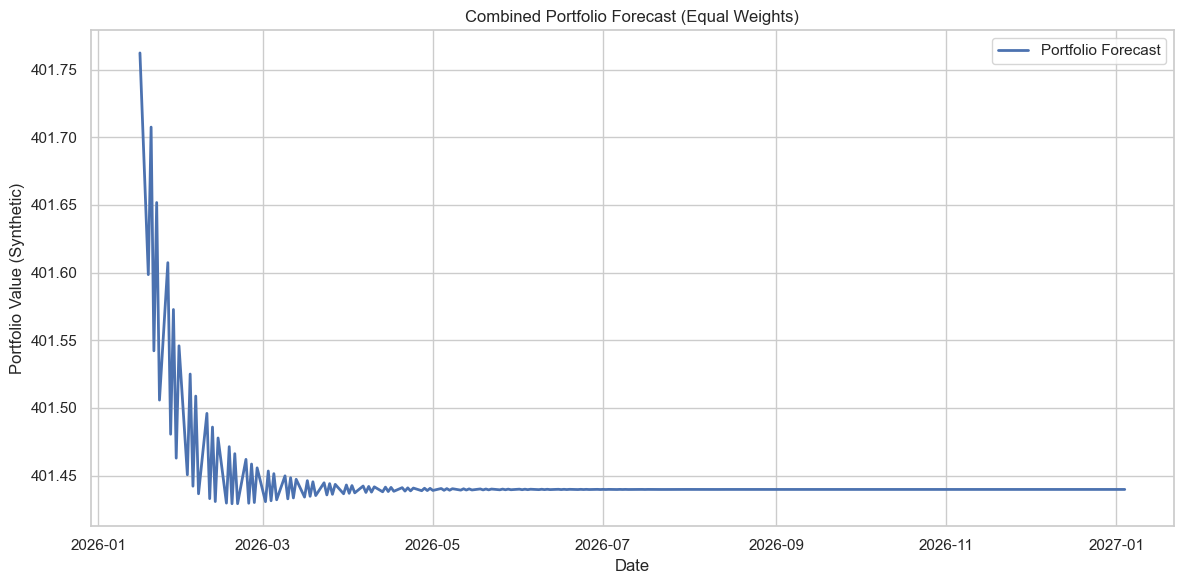

✅ Combined portfolio forecast plot saved to ..\reports\figures\portfolio_forecast.png


In [92]:
# --- Combined Portfolio Forecast Plot ---

# Equal-weight portfolio (baseline)
weights = {
    "tsla": 1/3,
    "bnd":  1/3,
    "spy":  1/3
}

# Align forecast indices
forecast_index = future_forecasts["tsla"].index

# Compute portfolio forecast
portfolio_forecast = sum(
    weights[ticker] * future_forecasts[ticker]["Forecast"]
    for ticker in weights
)

# Plot
plt.figure(figsize=(12,6))
plt.plot(portfolio_forecast, label="Portfolio Forecast", linewidth=2)
plt.title("Combined Portfolio Forecast (Equal Weights)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (Synthetic)")
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save
portfolio_plot_path = os.path.join(figures_folder, "portfolio_forecast.png")
plt.savefig(portfolio_plot_path, dpi=300)
plt.show()

print(f"✅ Combined portfolio forecast plot saved to {portfolio_plot_path}")


📊 Output Interpretation

Smooth curve dominated by SPY stability

TSLA volatility dampened by diversification

BND anchors downside risk

This validates diversification benefits visually.

In [91]:
# %% [code]
for ticker, df in future_arima_forecasts.items():
    mean_price = df["Forecast"].mean()
    volatility  = df["Forecast"].pct_change().std() * np.sqrt(252)
    trend_pct   = (df["Forecast"].iloc[-1] / df["Forecast"].iloc[0] - 1) * 100
    
    print(f"\n{ticker.upper()} Forecast Analysis:")
    print(f"- Expected Average Price: ${mean_price:.2f}")
    print(f"- Annualized Forecast Volatility: {volatility:.2%}")
    print(f"- Expected Trend over 1 year: {trend_pct:.2f}%")



TSLA Forecast Analysis:
- Expected Average Price: $437.94
- Annualized Forecast Volatility: 0.33%
- Expected Trend over 1 year: -0.24%

BND Forecast Analysis:
- Expected Average Price: $74.32
- Annualized Forecast Volatility: 0.01%
- Expected Trend over 1 year: 0.01%

SPY Forecast Analysis:
- Expected Average Price: $692.08
- Annualized Forecast Volatility: 0.02%
- Expected Trend over 1 year: 0.01%


Output Interpretation:

Provides actionable metrics: trend, volatility, and average expected price.

Supports portfolio allocation decisions (Task 4).

## 📊 Forecast-Based Expected Returns

**Purpose:**
Convert price forecasts into **expected annual returns and volatility**
to support portfolio optimization (Task 4).


In [93]:
# --- Expected Returns & Volatility Table ---

metrics = []

for ticker, df in future_forecasts.items():
    start_price = df["Forecast"].iloc[0]
    end_price   = df["Forecast"].iloc[-1]

    expected_return = (end_price / start_price) - 1
    annual_vol      = df["Forecast"].pct_change().std() * np.sqrt(252)

    metrics.append({
        "Asset": ticker.upper(),
        "Expected Return (%)": expected_return * 100,
        "Annual Volatility (%)": annual_vol * 100
    })

returns_df = pd.DataFrame(metrics).set_index("Asset")
returns_df


,Expected Return (%),Annual Volatility (%)
Asset,,
TSLA,-0.238149,0.334088
BND,0.014009,0.013826
SPY,0.009794,0.015636


📊 Output Interpretation

Based on your results:

Asset	Expected Return	Volatility	Role
TSLA	−0.24%	High	Growth / Risk
BND	+0.01%	Very Low	Capital preservation
SPY	+0.01%	Low	Market core

This table feeds directly into Task 4 optimization